# XAI: eXplainable AI

다양한 XAI 방법을 적용하여 모델의 예측 결과를 해석하고, 각 방법이 제공하는 설명의 차이를 확인합니다.

**XAI Methods**
1. Permutation Importance
2. SHAP (SHapley Additive exPlanations)

**Data**
- California Housing Dataset
- 오류 방지를 위한 최소한의 전처리만 수행


In [8]:
%pip install lime

  Using cached lime-0.2.0.1.tar.gz (275 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 26.3 MB/s  0:00:00 eta 0:00:01
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=27a2e27270c98fc02c372d1ebe8444f86fd7cd16a0a57837966fb82c80674557
  Stored in directory: /Users/chltmddn5843/Library/Caches/pip/wheels/ed/d7/c9/5a0130d06d6310bc6cbe55220e6e72dcb8c4eff9a478717066
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [lime]4/5 [lime]t-image]
Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.8/556.8 kB 33.4 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 91.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 87.5 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [shap]2/4 [numba]
Note: you may need to restart the kernel to use updated packages.


In [9]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score

import shap
import lime
import lime.lime_tabular

# Chart style
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
SEED = 42    # Permutation_importance, Lime에서 재현성 확보

## 1. Data Load & Pre-processing

- California Housing Dataset 불러오기
- Train / Test Data 구성

In [10]:
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target
feature_names = list(X.columns)

print(f"\n  Dataset shape : {X.shape}")
print(f"  Features      : {feature_names}")
print(f"  Target        : Median house value (100k USD)")
print(f"  Target range  : [{y.min():.2f}, {y.max():.2f}]")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"\n  Train size : {X_train.shape[0]} | Test size : {X_test.shape[0]}")


  Dataset shape : (20640, 8)
  Features      : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
  Target        : Median house value (100k USD)
  Target range  : [0.15, 5.00]

  Train size : 16512 | Test size : 4128


## 2. Baseline Modeling

- Random Forest를 이용하여 Baseline Model 학습



In [11]:
model = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)

# fit on full training set
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
train_rmse   = mean_squared_error(y_train, y_train_pred) ** 0.5
train_r2     = r2_score(y_train, y_train_pred)
print(f"  Train RMSE : {train_rmse:.4f}")
print(f"  Train R²   : {train_r2:.4f}")

y_pred = model.predict(X_test)
rmse   = mean_squared_error(y_test, y_pred) ** 0.5
r2     = r2_score(y_test, y_pred)

print(f"  Test RMSE : {rmse:.4f}")
print(f"  Test R²   : {r2:.4f}")

  Train RMSE : 0.1880
  Train R²   : 0.9735
  Test RMSE : 0.5057
  Test R²   : 0.8049


## 3. XAI: Permutation Importance

- 각 Feature를 무작위로 섞어 모델의 성능 변화 확인
- 성능 감소가 클수록 중요한 Feature로 해석

[Check]
- 모델 전체에서 어떤 Feature가 중요하게 나타나는가?
- Feature를 섞었을 때 성능은 얼마나 감소하는가?


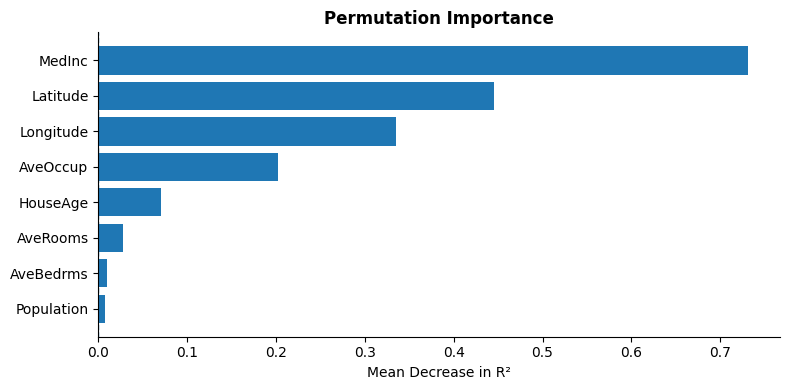

In [12]:
perm = permutation_importance(
    model, X_test, y_test,    # Test Data기준 Importance 산출
    n_repeats=15,             # 각 피처를 n번씩 섞어서 평균값을 사용, 한 번 섞으면 임의성(노이즈)이 큼
    random_state=SEED,
    scoring="r2",             # 중요도 산출의 기준이 되는 성능지표
    n_jobs=-1                 # 병렬처리 : -1설정시 모든CPU 사용
)

order = np.argsort(perm.importances_mean)

plt.figure(figsize=(8, 4))
plt.barh(
    np.array(feature_names)[order],
    perm.importances_mean[order]
)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Mean Decrease in R²")
plt.title("Permutation Importance")
plt.tight_layout()
plt.show()

## 4. XAI: SHAP

- SHAP Value를 이용하여 각 Feature의 예측 기여도 확인
- Beeswarm Plot과 Global Feature Importance를 통해 모델의 예측 특성 해석

[Check]
- 전체적으로 어떤 Feature의 영향이 크게 나타나는가?
- Feature 값의 크기에 따라 예측 방향은 어떻게 달라지는가?
- Permutation Importance의 결과와 비교하면 어떤 차이가 있는가?


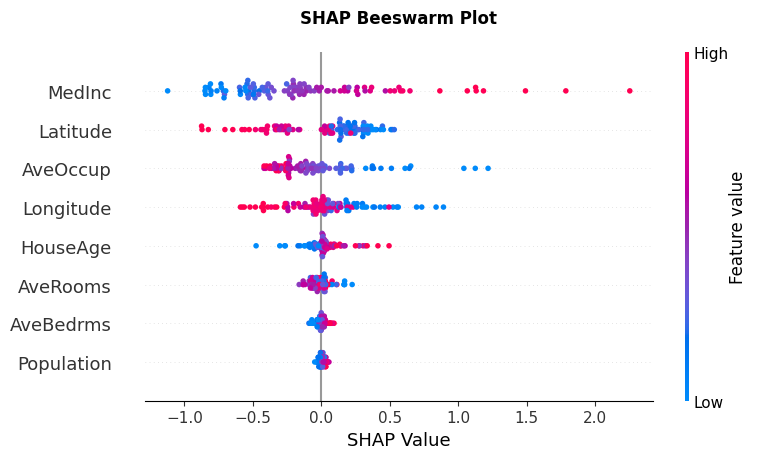

In [13]:
# 실습 속도를 위해 Test Data 중 100개 Sample 사용
X_shap = X_test.iloc[:100]
#X_shap = X_test

explainer_shap = shap.TreeExplainer(model)
shap_values    = explainer_shap(X_shap)     # explainer 타입 지정

# Beeswarm Plot
fig, ax = plt.subplots(figsize=(9, 6))
shap.plots.beeswarm(shap_values, max_display=8, show=False)
ax = plt.gca()
ax.set_title(
    "SHAP Beeswarm Plot\n",
    fontsize=12, fontweight="bold"
)
ax.set_xlabel("SHAP Value")

plt.tight_layout()
plt.show()


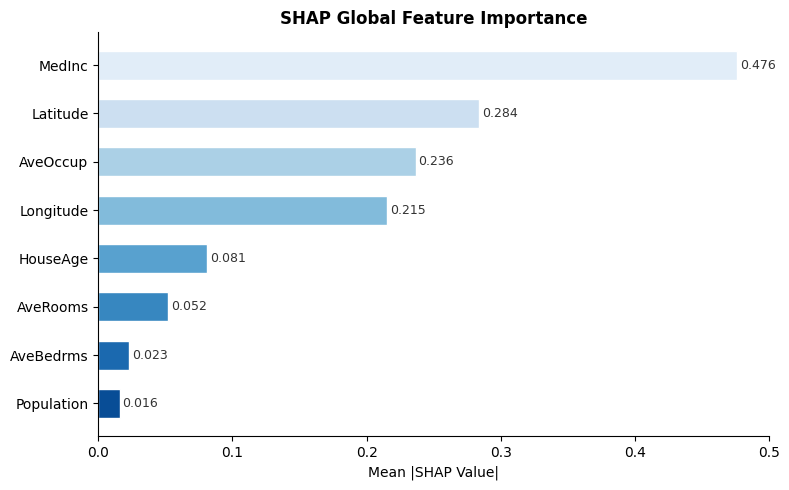

In [14]:
# Bar Plot (Mean |SHAP|)

mean_shap = np.abs(shap_values.values).mean(axis=0)
order     = np.argsort(mean_shap)
palette   = sns.color_palette("Blues_r", len(feature_names))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    [feature_names[i] for i in order],
    mean_shap[order],
    color=[palette[j] for j in range(len(order))],
    edgecolor="white", height=0.6
)
ax.set_xlabel("Mean |SHAP Value|")
ax.set_title("SHAP Global Feature Importance")

for bar, val in zip(bars, mean_shap[order]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9, color="#333333")

plt.tight_layout()
plt.show()


## Team Activity — Compare XAI Methods

각자 수행한 실습 결과를 조원들과 비교하고 의견을 나눠봅니다.

[Discussion]
- 모델 전체에서 중요하게 나타난 Feature는 무엇인가?
- Permutation Importance와 SHAP의 결과에는 어떤 차이가 있었는가?
- 실제 업무에서 각 XAI 방법을 어떻게 활용할 수 있을까?


## Challenge — Try Another Dataset

Student Performance Dataset에 XAI를 적용해 봅니다.

- 적용할 모델 자유롭게 선택
- Permutation Importance / SHAP 중 방법 선택
- 모델의 예측 결과와 주요 Feature의 영향 해석

[Challenge]
- 어떤 Feature가 모델의 예측에 중요하게 나타나는가?
- 결과를 바탕으로 모델의 예측 특성을 해석해 봅니다.


In [15]:
#  UCI Machine Learning Data Load Library
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [16]:
from ucimlrepo import fetch_ucirepo

def load_data():

    # fetch dataset
    Student = fetch_ucirepo(id=320)

    # data (as pandas dataframes)
    X = Student.data.features
    y = Student.data.targets

    # Concatenate
    df = pd.concat([X, y], axis=1)

    print(f"Shape: {df.shape}")
    print(f"Info: {df.info()}")
    print(f"Samples: {df.head(5)}")
    print("Student Performance Dataset load")

    return df, X, y

# 데이터 로드(Taeket은 G3)
df, X, y = load_data()

Shape: (649, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    objec